In [25]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

**Processing steps**:
1. Load data
2. Merge on Year/Month/Day/Hour/Minute/Second -> Single datetime index
3. Handling missing values with strict linear interpolation to prevent forward-looking leakage, `limit=3` for short NaN gaps (← 3 hours = continuous atmosphere)
   
   a) Avoids overfitting across day/night transitions
   
   b) Drops rows with > 3 consecutive NaNs (instrument outage)

4. Maps raw SMEAR column names (KUM_*) to physics names

In [28]:
# Load Base Data
df_gas = pd.read_csv('Gas_Full.csv')
df_bc = pd.read_csv('BC_Full.csv')
df_met = pd.read_csv('Meteorology_Full.csv')

time_cols = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']
df_merged = df_gas.merge(df_bc, on=time_cols).merge(df_met, on=time_cols)

# Create proper time index
df_merged['Datetime'] = pd.to_datetime(df_merged[time_cols])
df_merged.set_index('Datetime', inplace=True)
df_merged.drop(columns=time_cols, inplace=True)

# Quality Control: Interpolate short gaps (limit=3 hours) and drop the rest
df_base = df_merged.interpolate(method='linear', limit=3).dropna().copy()

# Rename variables to physical meanings
rename_dict = {
    'KUM_GAS.NO_x': 'NOx', 'KUM_GAS.SO_2': 'SO2', 
    'KUM_GAS.O_3': 'O3', 'KUM_GAS.CO': 'CO',
    'KUM_AERO.BC_MAAP': 'BC', 'KUM_META.p_station': 'Pressure',
    'KUM_META.hmp155_t': 'Temperature', 'KUM_META.hmp155_rh': 'Relative_Humidity',
    'KUM_META.Tower_WDIR_32m': 'Wind_Dir'
}
df_base.rename(columns=rename_dict, inplace=True)
print(f"Base data ready. Shape: {df_base.shape}")

Base data ready. Shape: (1463, 9)


**Baseline**

We enforce an 80/20 chronological split and employ **TimeSeriesSplit (TSCV)** for hyperparameter tuning. We force the model to learn from September's convective states and extrapolate into late October's stable polar states.

In [31]:
# Baseline strict chronological split (80/20)
split_idx = int(len(df_base) * 0.8)
X_base = df_base.drop(columns=['BC'])
y_base = df_base['BC']

X_train_base, X_test_base = X_base.iloc[:split_idx], X_base.iloc[split_idx:]
y_train_base, y_test_base = y_base.iloc[:split_idx], y_base.iloc[split_idx:]

# Baseline Model with TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
rf_baseline = RandomForestRegressor(random_state=42, n_estimators=100)
rf_baseline.fit(X_train_base, y_train_base)
base_pred = rf_baseline.predict(X_test_base)

print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test_base, base_pred)):.4f}")
print(f"Baseline R²: {r2_score(y_test_base, base_pred):.4f}")
imp_bl = pd.DataFrame({'Feature': X_train_base.columns, 'Importance': rf_baseline.feature_importances_}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance (top 5):")
print(imp_bl.head(5))

Baseline RMSE: 152.0450
Baseline R²: 0.3403

Feature Importance (top 5):
             Feature  Importance
3                 CO    0.811536
5           Wind_Dir    0.035297
6        Temperature    0.033417
4           Pressure    0.032134
7  Relative_Humidity    0.028456


Why **80/20 Chronological Split** and **TimeSeriesSplit (TSCV)**?

In [34]:
# High preformance but wrong step
X_try = df_base.drop(columns=['BC'])
y_try = df_base['BC']

X_train_fake, X_test_fake, y_train_fake, y_test_fake = train_test_split(
    X_try, y_try, test_size=0.2, random_state=42, shuffle=True
)
rf_fake = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_fake.fit(X_train_fake, y_train_fake)
fake_rmse = np.sqrt(mean_squared_error(y_test_fake, rf_fake.predict(X_test_fake)))
fake_r2 = r2_score(y_test_fake, rf_fake.predict(X_test_fake))
print(f"Flawed Random Shuffle RMSE: {fake_rmse:.4f}, R²: {fake_r2:.4f} (Illusion of high performance due to data leakage)")

Flawed Random Shuffle RMSE: 95.0229, R²: 0.8797 (Illusion of high performance due to data leakage)


If model evaluation employs Random Shuffle Cross-Validation or shortens the time window to a 50/50 split, the $R^2$ can easily soar above 0.80. 

However, this is physically absurd:
1. Using $t+1$ to predict $t$ can cause sever Autocorrelation Leakage.
2. 50/50 split completely avoids the core climatic shift from Helsinki's autumn to the polar night transition.

To evaluate the model's true forecasting skill, this study refuses to compromise.

**Try to improve R²**

Another problem, we found that **BC and CO are co-emitted** as below. 

Feature Importance (top 5):

index |  Feature | Importance
             
3 |    CO    | 0.811536

5 | Wind_Dir | 0.035297


When we predict BC directly, RF learns that CO explains 80%+ of variance, completely masking meteorological physics.

**Solution**: 
We predict BC/CO ratio (emission & deposition ratio) with input features including only thermodynamic, dynamic, and chemical aging proxies.
Model learns how weather systems modify the particle deposition fraction, not emission magnitude. Finally, we reconstruct BC by predicted_ratio × actual_CO.
This eliminates the surrogate trap where the tree just becomes a linear CO↔BC converter.

In summary, to improve forecasting without cheating, we can fuse Domain Knowledge with Machine Learning:
1. Applying non-linear median filtering to remove high-frequency instrument noise while preserving atmospheric meso-scale signals.
2. Extracting thermodynamic stability proxies (e.g., Dew Point, Temperature Change Rate) and decomposing wind vectors.
3. Random Forests cannot extrapolate magnitudes well. Since BC and CO are co-emitted from combustion, we shift the learning target to the **BC/CO Emission Ratio**, forcing the model to learn atmospheric deposition/dilution rather than raw emission volume.
4. Intentionally drop all absolute gas concentrations ($CO, NO_x, SO_2, O_3$) from the feature space. We force the algorithm to map purely meteorological and chemical aging variables to the deposition ratio.

In [41]:
df_phys = df_base.copy()

# Step 1: Signal Processing & Quality Control
features_to_filter = ['NOx', 'SO2', 'O3', 'CO', 'Temperature', 'Relative_Humidity', 'Pressure']
for col in features_to_filter:
    df_phys[col] = df_phys[col].rolling(window=3, center=False, min_periods=1).median()
df_phys['BC'] = df_phys['BC'].rolling(window=3, center=False, min_periods=1).median()
df_phys.dropna(inplace=True)

# Step 2: Physical & Thermodynamic Derivation
a, b = 17.27, 237.3
alpha = (a * df_phys['Temperature']) / (b + df_phys['Temperature']) + np.log(df_phys['Relative_Humidity'] / 100.0)
df_phys['Dew_Point'] = (b * alpha) / (a - alpha)
df_phys['Temp_Change_Rate'] = df_phys['Temperature'].diff().fillna(0)

wind_rad = np.deg2rad(df_phys['Wind_Dir'])
df_phys['Wind_U'] = -np.sin(wind_rad)
df_phys['Wind_V'] = -np.cos(wind_rad)

# Step 3: Chemistry Proxies (Breaking CO Hegemony)
df_phys['Plume_Age_Ratio'] = df_phys['CO'] / (df_phys['NOx'] + 1e-5)
df_phys['Oxidation_Capacity'] = df_phys['O3'] / (df_phys['NOx'] + 1e-5)

# Step 4: Constructing Physics-Informed Target
df_phys['BC_CO_Ratio'] = df_phys['BC'] / (df_phys['CO'] + 1e-5)

# Forcing the model to learn physics by dropping ALL absolute gas concentrations
features_strict = [
    'Dew_Point', 'Temp_Change_Rate', 'Wind_U', 'Wind_V',
    'Plume_Age_Ratio', 'Oxidation_Capacity', 'Pressure', 'Temperature', 'Relative_Humidity'
]

X_phys = df_phys[features_strict].copy()
y_phys_ratio = df_phys['BC_CO_Ratio'].copy()

# Keep true values for final physical reconstruction
CO_true = df_phys['CO'].copy()
BC_true = df_phys['BC'].copy()

print(f"Physics Feature Space Ready. Shape: {X_phys.shape}")

Physics Feature Space Ready. Shape: (1463, 9)


We now retrain the model using TimeSeriesSplit GridSearch on our physically constrained feature space.

In [44]:
# Executing Strict Chronological Split (80/20)
split_idx_phys = int(len(X_phys) * 0.8)

X_train_phys, X_test_phys = X_phys.iloc[:split_idx_phys], X_phys.iloc[split_idx_phys:]
y_train_ratio, y_test_ratio = y_phys_ratio.iloc[:split_idx_phys], y_phys_ratio.iloc[split_idx_phys:]
BC_test_true = BC_true.iloc[split_idx_phys:]
CO_test_true = CO_true.iloc[split_idx_phys:]

# Training Ratio-Targeted Random Forest (Using the exact parameters from our 0.4941 success)
rf_pim = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_leaf=4, 
                               max_features='sqrt', random_state=42, n_jobs=-1)
rf_pim.fit(X_train_phys, y_train_ratio)

# Physical Reconstruction
ratio_pred = rf_pim.predict(X_test_phys)
BC_pred_reconstructed = ratio_pred * CO_test_true

# Evaluation
rmse_phys = np.sqrt(mean_squared_error(BC_test_true, BC_pred_reconstructed))
r2_phys = r2_score(BC_test_true, BC_pred_reconstructed)

print(f"RMSE: {rmse_phys:.4f}")
print(f"R² Score: {r2_phys:.4f}")

# Feature Importance
imp_pim = pd.DataFrame({
    'Feature': X_train_phys.columns, 
    'Importance': rf_pim.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\n--- Core Physical Drivers for Aerosol Deposition Ratio ---")
print(imp_pim)

RMSE: 128.6566
R² Score: 0.4831

--- Core Physical Drivers for Aerosol Deposition Ratio ---
              Feature  Importance
5  Oxidation_Capacity    0.250226
2              Wind_U    0.191201
4     Plume_Age_Ratio    0.149500
6            Pressure    0.103400
0           Dew_Point    0.096279
3              Wind_V    0.065975
7         Temperature    0.065907
8   Relative_Humidity    0.043619
1    Temp_Change_Rate    0.033893


Note: Despite exhaustive physical feature engineering on the basic dataset, the model hits a predictive ceiling of **~0.48 (R²) from Baseline R²: 0.3403**. To break this, we must introduce external micro-meteorological forcing data (Wet Scavenging & Radiation).

Considering the following equation —— Atmospheric BC Mass Balance:

$$\frac{\partial C_{BC}}{\partial t} = \underbrace{S_{\text{emis}}}_{\text{Sources}} + \underbrace{-\mathbf{u} \cdot \nabla C - w \frac{\partial C}{\partial z}}_{\text{Advection}} - \underbrace{D_{\text{dry}} - D_{\text{wet}}}_{\text{Sinks}}$$

Black carbon concentration change = **Sources** + **Transport** - **Dilution** - **Sinks**

Our initial features captured:
- Sources & Transport: Plume_Age_Ratio (CO/NOx), Wind vectors
- Thermodynamics: Temperature, Dew_Point, RH (mixing state)

**Missing mechanisms** (That's the reason why I added the followinng variables via SMEAR bonus data):
- Dilution (Sinks): No wet deposition data
- Dilution (Boundary Layer): No radiation to track convective mixing
- Fluxes: No direct measure of turbulent heat exchange

The SMEAR III bonus data (rainfall, radiation, sensible heat flux) directly quantifies these physical processes, enabling a complete atmospheric mass balance representation.

**The bonus data I chose includes**: 

Global Radiation → Clipped to [0, ∞)
- Night: Negative values = instrument radiating to cold sky (physics artifact)
- Purpose: Threshold at 5 W/m² for Is_Daylight binary (captures daytime regimes)

Cumulative Rainfall → 6-hour rolling sum
- Time scale: ~6 hours = typical scavenging residence time in rain shaft
- Multiple sensors → Take MAX (if any sensor detects, rain occurred)

Sensible Heat Flux → Sign extraction for BL_Instability  
- H > 0: Ground heating air → vertical mixing → BC diluted in larger volume
- H < 0: Ground cooling → stable layers → BC trapped → concentration increases

In [50]:
# 1. Loading Bonus Meteorological & Flux Data
df_rain = pd.read_csv('rainfall.csv')
df_flux = pd.read_csv('flux.csv')
df_rad = pd.read_csv('radiation.csv')

# Rigorous time alignment function (algorithmic necessity: slight misalignment in time series leads to catastrophic target leakage)
def make_dt_index(df):
    return pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']])

df_rain.index = make_dt_index(df_rain)
df_flux.index = make_dt_index(df_flux)
df_rad.index = make_dt_index(df_rad)

# 2. Applying Physics-based Transformations

# (1) Radiation: truncate physically meaningless negative values caused by nighttime instrument cooling
# There is no such thing as "negative solar shortwave radiation" in physics.
# Negative nighttime values are instrument noise from the radiometer's glass dome cooling via longwave radiation to the night sky.
# Without truncating to 0, the model would attempt to learn nonsensical nonlinear rules from these negative noises.
global_rad = df_rad['KUM_RAD.Tower_GLOB_32m'].clip(lower=0)

# (2) Precipitation: fill NaN, fuse multiple sensors, extract "cumulative wet scavenging effect"
# Aerosol wet scavenging (washout) is not instantaneous but a cumulative process.
# Taking the maximum across multiple rain gauges prevents false negatives caused by a single sensor failure or insensitivity to drizzle.
df_rain.fillna(0, inplace=True)
rain_intensity = df_rain[['KUM_META.rmm', 'KUM_META.pwd_intensity_w', 'KUM_META.pwd_rmm']].max(axis=1)
cumulative_rain_6h = rain_intensity.rolling(window=6, min_periods=1).sum()

# (3) Sensible heat flux: linear interpolation to repair small gaps
# Eddy covariance instruments produce very short data gaps during precipitation or extremely low wind speeds.
sensible_heat = df_flux['KUM_EDDY.H'].interpolate(method='linear')

# Construct the Bonus feature set
bonus_features = pd.DataFrame({
    'Global_Radiation': global_rad,
    'Sensible_Heat_Flux': sensible_heat,
    'Cumulative_Rain_6h': cumulative_rain_6h
})

# Strict timestamp-aligned merge with our previous perfect df_phys (base physics dataset)
df_ultimate = df_phys.join(bonus_features, how='inner')
df_ultimate.dropna(inplace=True) # Remove a few boundary NaNs introduced by rolling

print(f"Ultimate Data Shape: {df_ultimate.shape}")

# 3. Preparing the Final Feature Space (Sinks + Dilution + Transport)
# This is an extremely comprehensive physics-based feature space, covering almost all components of the atmospheric mass balance equation
features_ultimate = [
    'Wind_U', 'Wind_V',                      # Advective transport
    'Plume_Age_Ratio', 'Oxidation_Capacity', # Photochemical source / aging (chemical proxies)
    'Dew_Point', 'Pressure', 'Temperature',  # Thermodynamic background
    'Global_Radiation',                      # Radiation-driven boundary layer dilution
    'Sensible_Heat_Flux',                    # Turbulent mixing capability
    'Cumulative_Rain_6h'                     # Wet scavenging sink
]

X_ult = df_ultimate[features_ultimate]
y_ratio_ult = df_ultimate['BC_CO_Ratio']
BC_true_ult = df_ultimate['BC']
CO_true_ult = df_ultimate['CO']

# 4. Executing Strict Chronological Split
split_idx_u = int(len(df_ultimate) * 0.8)

X_train_u, X_test_u = X_ult.iloc[:split_idx_u], X_ult.iloc[split_idx_u:]
y_ratio_train_u, y_ratio_test_u = y_ratio_ult.iloc[:split_idx_u], y_ratio_ult.iloc[split_idx_u:]
BC_test_true_u = BC_true_ult.iloc[split_idx_u:]
CO_test_true_u = CO_true_ult.iloc[split_idx_u:]

# 5 & 6. Training & Physical Reconstruction Evaluation
rf_ultimate = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_leaf=4, 
                                    max_features='sqrt', random_state=42, n_jobs=-1)
rf_ultimate.fit(X_train_u, y_ratio_train_u)

ratio_pred_u = rf_ultimate.predict(X_test_u)
BC_pred_reconstructed_u = ratio_pred_u * CO_test_true_u

rmse_u = np.sqrt(mean_squared_error(BC_test_true_u, BC_pred_reconstructed_u))
mae_u = mean_absolute_error(BC_test_true_u, BC_pred_reconstructed_u)
r2_u = r2_score(BC_test_true_u, BC_pred_reconstructed_u)
print(f"RMSE: {rmse_u:.4f}")
print(f"MAE:  {mae_u:.4f}")
print(f"R²:   {r2_u:.4f}")

imp_u = pd.DataFrame({
    'Feature': X_train_u.columns, 
    'Importance': rf_ultimate.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("Ranking")
print(imp_u.to_string(index=False))

Ultimate Data Shape: (1413, 19)
RMSE: 122.6638
MAE:  96.4023
R²:   0.5465
Ranking
           Feature  Importance
Oxidation_Capacity    0.254578
            Wind_U    0.178404
   Plume_Age_Ratio    0.145076
          Pressure    0.099766
         Dew_Point    0.098920
       Temperature    0.070507
            Wind_V    0.068139
Cumulative_Rain_6h    0.035096
Sensible_Heat_Flux    0.029341
  Global_Radiation    0.020174


**Nice! We improve R² from 0.4831 to 0.5465 by using bonus data!**

How to improve R² furthermore, we have a hypothesis.

The hypothesis is **Covariate Shift**. Random Forests are partition-based algorithms; they mathematically cannot extrapolate beyond the feature domain seen in the training data (Out-of-Distribution, OOD). As Helsinki transitions from September (training) to late October (testing), the atmospheric baseline (especially radiation and temperature) drifts dramatically toward the polar night regime. 

To scientifically prove this, we deploy the **Two-Sample Kolmogorov-Smirnov (KS) Test**:
- **$H_0$:** The distributions of the feature in the training and test sets are identical.
- **$H_a$:** The distributions are fundamentally different.
A $p$-value $< 0.05$ strictly flags a feature as "shifted", essentially acting as poison for the Random Forest's leaf nodes.


Comparing feature distributions: Training (Sep/Early Oct) vs. Test (Late Oct) (Null Hypothesis (H0): Distributions are identical.)

If p-value < 0.05, H0 is rejected -> Significant Covariate Shift detected.

In [56]:
from scipy.stats import ks_2samp

shifted_features = []
stable_features = []

for col in X_train_u.columns:
    # KS 检验：计算两个累积分布函数(CDF)的最大距离 (KS-Stat) 和 p-value
    stat, p_val = ks_2samp(X_train_u[col], X_test_u[col])
    
    if p_val < 0.05:
        shifted_features.append(col)
        status = "SHIFTED (OOD Extrapolation Trap)"
    else:
        stable_features.append(col)
        status = "STABLE (Safe for RF)"
        
    print(f"[{col:<20}] KS-Stat: {stat:.4f}, p-value: {p_val:.4e} -> {status}")

print("\n--- Diagnostic Conclusion ---")
print(f"Total Features Evaluated: {len(X_train_u.columns)}")
print(f"Features with Significant Drift: {len(shifted_features)}")

[Wind_U              ] KS-Stat: 0.1555, p-value: 3.0562e-05 -> SHIFTED (OOD Extrapolation Trap)
[Wind_V              ] KS-Stat: 0.3214, p-value: 3.1571e-21 -> SHIFTED (OOD Extrapolation Trap)
[Plume_Age_Ratio     ] KS-Stat: 0.2109, p-value: 2.6533e-09 -> SHIFTED (OOD Extrapolation Trap)
[Oxidation_Capacity  ] KS-Stat: 0.2008, p-value: 1.7335e-08 -> SHIFTED (OOD Extrapolation Trap)
[Dew_Point           ] KS-Stat: 0.5071, p-value: 7.7237e-54 -> SHIFTED (OOD Extrapolation Trap)
[Pressure            ] KS-Stat: 0.5387, p-value: 3.2612e-61 -> SHIFTED (OOD Extrapolation Trap)
[Temperature         ] KS-Stat: 0.6283, p-value: 3.5849e-85 -> SHIFTED (OOD Extrapolation Trap)
[Global_Radiation    ] KS-Stat: 0.2232, p-value: 2.2154e-10 -> SHIFTED (OOD Extrapolation Trap)
[Sensible_Heat_Flux  ] KS-Stat: 0.1666, p-value: 5.7817e-06 -> SHIFTED (OOD Extrapolation Trap)
[Cumulative_Rain_6h  ] KS-Stat: 0.5886, p-value: 7.1927e-74 -> SHIFTED (OOD Extrapolation Trap)

--- Diagnostic Conclusion ---
Total Fea

The atmospheric baseline in late October has fundamentally collapsed compared to September. 

The Random Forest is being forced to make predictions on micro-meteorological values (e.g., Radiation, Thermodynamics) it has never seen before, triggering algorithmic failure.

To break this theoretical ceiling, we must reconstruct the feature space using localized, scale-invariant physics (Dynamic Rolling Z-Scores).

The Kolmogorov-Smirnov (KS) test reveals a critical issue: 100% of the evaluated meteorological and chemical proxy features exhibit significant distribution drift ($p < 0.05$) between the training set (September) and the test set (late October). 

This is not a data error, but a physical reality. As Helsinki transitions towards the polar night, the atmospheric boundary layer undergoes a fundamental regime shift—from a convection-driven system dominated by solar radiation to a stable inversion system driven by surface cooling. Random Forest models inherently fail at Out-of-Distribution (OOD) extrapolation. When the model encounters radiation and temperature values in late October that never existed in September, the decision trees cannot effectively split the data.

To mitigate this covariate shift, the first mathematical approach is dynamic normalization: converting absolute continuous values into relative local anomalies (Rolling Z-Scores) to force distribution stability.


In [60]:
window_size = 72

df_robust = df_ultimate.copy()

vars_to_normalize = ['Global_Radiation', 'Sensible_Heat_Flux', 'Temperature', 'Dew_Point']

for var in vars_to_normalize:
    rolling_mean = df_robust[var].rolling(window=window_size, min_periods=24).mean()
    rolling_std = df_robust[var].rolling(window=window_size, min_periods=24).std() + 1e-5 
    df_robust[f'{var}_Anomaly'] = (df_robust[var] - rolling_mean) / rolling_std

df_robust.dropna(inplace=True)

# Re-evaluate KS Test on Anomalies
split_idx_robust = int(len(df_robust) * 0.8)
X_train_rob = df_robust.iloc[:split_idx_robust]
X_test_rob = df_robust.iloc[split_idx_robust:]

print("=== Re-evaluating KS Test on Dynamic Anomalies ===")
for var in vars_to_normalize:
    col = f'{var}_Anomaly'
    stat, p_val = ks_2samp(X_train_rob[col], X_test_rob[col])
    status = "SHIFTED" if p_val < 0.05 else "STABLE"
    print(f"[{col:<25}] KS-Stat: {stat:.4f}, p-value: {p_val:.4e} -> {status}")

=== Re-evaluating KS Test on Dynamic Anomalies ===
[Global_Radiation_Anomaly ] KS-Stat: 0.3381, p-value: 4.8187e-23 -> SHIFTED
[Sensible_Heat_Flux_Anomaly] KS-Stat: 0.1799, p-value: 9.7564e-07 -> SHIFTED
[Temperature_Anomaly      ] KS-Stat: 0.1888, p-value: 2.1856e-07 -> SHIFTED
[Dew_Point_Anomaly        ] KS-Stat: 0.2491, p-value: 1.3835e-12 -> SHIFTED


Mathematical normalization (Z-score) is insufficient to resolve the regime shift, as $p$-values remain near zero. The fundamental reason is that mathematical scaling cannot equate "nighttime inversion" with "daytime convection." The seasonal shift structurally alters the diurnal patterns.

If continuous variables inevitably drift, the physically sound solution is to degrade these continuous forcings into binary state variables. Instead of forcing the model to extrapolate absolute radiation values ($W/m^2$), we provide boundary layer status flags (e.g., Daylight availability, Boundary Layer Instability). Combined with Time Series Cross-Validation (TSCV), this limits the model to learning generalized physical rules rather than memorizing seasonal numerical ranges.

In [63]:
df_final = df_robust.copy()

# Degrade continuous drifting variables into binary state flags
df_final['Is_Daylight'] = (df_final['Global_Radiation'] > 5.0).astype(int)
df_final['BL_Instability'] = (df_final['Sensible_Heat_Flux'] > 0).astype(int)

# Define the robust feature space (excluding absolute drifting variables)
features_robust = [
    'Wind_U', 'Wind_V', 
    'Plume_Age_Ratio', 'Oxidation_Capacity', 
    'Cumulative_Rain_6h',                  
    'Is_Daylight', 'BL_Instability'        
]

X_rob = df_final[features_robust]
y_ratio_rob = df_final['BC_CO_Ratio'] 
BC_true_rob = df_final['BC']
CO_true_rob = df_final['CO']

split_idx = int(len(df_final) * 0.8)

X_train = X_rob.iloc[:split_idx]
X_test = X_rob.iloc[split_idx:]
y_train = y_ratio_rob.iloc[:split_idx]

BC_test_true = BC_true_rob.iloc[split_idx:]
CO_test_true = CO_true_rob.iloc[split_idx:]

# Time Series Cross-Validation to prevent look-ahead bias
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [6, 10, 15],
    'min_samples_leaf': [4, 10, 20],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# Final Prediction and Reconstruction
ratio_pred = best_rf.predict(X_test)
BC_pred_final = ratio_pred * CO_test_true

rmse_final = np.sqrt(mean_squared_error(BC_test_true, BC_pred_final))
mae_final = mean_absolute_error(BC_test_true, BC_pred_final)
r2_final = r2_score(BC_test_true, BC_pred_final)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"RMSE: {rmse_final:.4f}")
print(f"MAE:  {mae_final:.4f}")
print(f"R²:   {r2_final:.4f}\n")

imp_df = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("--- Feature Importance ---")
print(imp_df.to_string(index=False))

Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 300}
RMSE: 117.9526
MAE:  96.1763
R²:   0.5865

--- Feature Importance ---
           Feature  Importance
Oxidation_Capacity    0.338186
            Wind_U    0.256314
   Plume_Age_Ratio    0.194304
            Wind_V    0.112038
Cumulative_Rain_6h    0.069393
       Is_Daylight    0.020830
    BL_Instability    0.008934


To be honest, I struggle here for long time, it's really hard to improve the evaluation index easily. R²: 0.5865 is already very good for thos kind of task. Then I realize that there still exists some points that might be useful for the final result without data leaking.

**Attempt: Augmenting Features with BC Lag Terms**

The robust model above hits a predictive ceiling of roughly $R^2 \approx 0.58$ when using only binary boundary-layer flags and chemical proxies. One natural extension is to exploit the strong **temporal autocorrelation** of atmospheric black carbon: if concentration was elevated one hour ago, it is likely still elevated now. This motivates adding *autoregressive* (lag) features of the form $BC_{t-k}$ for $k = 1, 2, 3, 6, 12$ hours, together with short rolling means over the immediate past.

Additional feature engineering improvements applied simultaneously:

1. **Log-transform the BC target** — raw BC concentrations are heavily right-skewed (occasional pollution spikes). Taking $\log(1 + BC)$ produces a near-Gaussian distribution, so the forest minimises error across the full concentration range rather than overfitting to rare extremes.
2. **Log-scale all gas concentrations** — $\log(1 + CO)$, $\log(1 + NO_x)$, etc. compress the dynamic range of each species, preventing any single gas from monopolising variance through its outlier tail (previously CO alone explained $>80\%$ of variance).
3. **Cyclic temporal features** — hour of day and day of year encoded as $(\sin, \cos)$ pairs, plus a weekend binary flag. These are bounded in $[-1, 1]$ regardless of season and capture the human-activity rhythms (rush-hour combustion, heating demand) that drive emission variability.
4. **Rolling meteorology** — 3-hour rolling means of temperature, relative humidity, and global radiation, smoothing instrument noise while preserving mesoscale boundary-layer dynamics.

In [65]:
# Log-scaled gas concentrations (compresses outlier tails)
df_final['log_NOx'] = np.log1p(df_final['NOx'])
df_final['log_SO2'] = np.log1p(df_final['SO2'])
df_final['log_CO']  = np.log1p(df_final['CO'])
df_final['log_O3']  = np.log1p(df_final['O3'])

# Cyclic temporal features (bounded [-1, 1] — no seasonal drift)
df_final['Hour_sin']      = np.sin(2 * np.pi * df_final.index.hour       / 24)
df_final['Hour_cos']      = np.cos(2 * np.pi * df_final.index.hour       / 24)
df_final['Is_Weekend']    = (df_final.index.dayofweek >= 5).astype(int)
df_final['DayOfYear_sin'] = np.sin(2 * np.pi * df_final.index.dayofyear  / 365)
df_final['DayOfYear_cos'] = np.cos(2 * np.pi * df_final.index.dayofyear  / 365)

# Rolling meteorology (3-hour window; no shift needed — these are exogenous)
df_final['Temp_roll3'] = df_final['Temperature'].rolling(3, min_periods=1).mean()
df_final['RH_roll3']   = df_final['Relative_Humidity'].rolling(3, min_periods=1).mean()
df_final['Rad_roll3']  = df_final['Global_Radiation'].rolling(3, min_periods=1).mean()

# BC autoregressive lag features
# shift(k) ensures row t uses BC from time t-k (no look-ahead into t itself)
for k in [1, 2, 3, 6, 12]:
    df_final[f'BC_lag{k}'] = df_final['BC'].shift(k)

# Rolling means of past BC (shift(1) before rolling prevents t leaking into window)
df_final['BC_roll3_mean'] = df_final['BC'].shift(1).rolling(3).mean()
df_final['BC_roll6_mean'] = df_final['BC'].shift(1).rolling(6).mean()

# Log-transform the target
df_final['log_BC'] = np.log1p(df_final['BC'])

df_final.dropna(inplace=True)
print(f"Dataset after lag feature engineering: {df_final.shape}")

Dataset after lag feature engineering: (1378, 45)


In [89]:
# Feature set and chronological split
FEATURES_AUGMENTED = [
    'Wind_U', 'Wind_V',
    'Plume_Age_Ratio', 'Oxidation_Capacity',
    'Temperature', 'Dew_Point', 'Pressure', 'Relative_Humidity',
    'Global_Radiation', 'Sensible_Heat_Flux', 'Cumulative_Rain_6h',
    'Is_Daylight', 'BL_Instability',
    'Hour_sin', 'Hour_cos', 'Is_Weekend', 'DayOfYear_sin', 'DayOfYear_cos',
    'log_NOx', 'log_CO', 'log_SO2', 'log_O3',
    'Temp_roll3', 'RH_roll3', 'Rad_roll3',
    'BC_lag1', 'BC_lag2', 'BC_lag3', 'BC_lag6', 'BC_lag12',
    'BC_roll3_mean', 'BC_roll6_mean',
]

split_idx = int(len(df_final) * 0.80)

X_train_aug = df_final[FEATURES_AUGMENTED].iloc[:split_idx]
X_test_aug  = df_final[FEATURES_AUGMENTED].iloc[split_idx:]
y_train_aug = df_final['log_BC'].iloc[:split_idx]
y_test_aug  = df_final['log_BC'].iloc[split_idx:]

y_train_raw = df_final['BC'].iloc[:split_idx]
y_test_raw  = df_final['BC'].iloc[split_idx:]

# Train and evaluate
rf_aug = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_aug.fit(X_train_aug, y_train_aug)

# Inverse-transform log predictions back to ng/cm³
y_pred_aug_train = np.expm1(rf_aug.predict(X_train_aug))
y_pred_aug_test  = np.expm1(rf_aug.predict(X_test_aug))

r2_aug_train = r2_score(y_train_raw, y_pred_aug_train)
r2_aug_test  = r2_score(y_test_raw,  y_pred_aug_test)
rmse_aug     = np.sqrt(mean_squared_error(y_test_raw, y_pred_aug_test))
mae_aug      = mean_absolute_error(y_test_raw, y_pred_aug_test)

print(f"Training R²: {r2_aug_train:.4f}")
print(f"Test     R²: {r2_aug_test:.4f}")
print(f"RMSE: {rmse_aug:.2f} ng/cm³,  MAE: {mae_aug:.2f} ng/cm³")

# Feature importances
imp_aug = pd.DataFrame({
    'Feature': FEATURES_AUGMENTED,
    'Importance': rf_aug.feature_importances_
}).sort_values('Importance', ascending=False)
print("--- Feature Importance ---")
print(imp_aug.head(10).to_string(index=False))

Training R²: 0.9750
Test     R²: 0.8275
RMSE: 75.73 ng/cm³,  MAE: 52.53 ng/cm³
--- Feature Importance ---
           Feature  Importance
           BC_lag1    0.212551
     BC_roll3_mean    0.132276
            log_CO    0.128590
           BC_lag2    0.112540
     BC_roll6_mean    0.075063
           log_NOx    0.059653
           BC_lag3    0.055017
Oxidation_Capacity    0.049048
           BC_lag6    0.027265
   Plume_Age_Ratio    0.023935


**But soon I realize that this is wrong!**

**Critical Flaw: Test-Set Leakage in the BC Lag Features**

The augmented model yields a test $R^2 \approx 0.81$, a substantial improvement in appearance. However, this figure is **inflated by data leakage** and must be rejected on the same grounds as the random-shuffle split discussed earlier.

Consider the evaluation loop. The test set begins at 00:00 on 20 October. The first test row uses $BC_{t-1}$ from 23:00 on 19 October — a true training-set value, which is legitimate. The second test row corresponds to 01:00 on 20 October. Its $BC\_lag1$ is set to the true observed $BC$ at 00:00 on 20 October — **a test-set value the model has not predicted yet.** In a real operational scenario, when predicting concentrations for the coming days from 19 October, this value is unknowable.

This is structurally identical to the autocorrelation leakage problem identified for the random-shuffle split: because atmospheric BC has very strong hour-to-hour persistence ($r \approx 0.9$ at lag 1), a model that has access to the true previous observation effectively already "knows" most of the answer. The Random Forest degenerates into a **naïve persistence forecaster** — it learns the rule $\hat{BC}_t \approx BC_{t-1}$, which requires no atmospheric understanding at all.

The inflated $R^2$ can be quantified precisely:

$$\Delta R^2_{\text{leakage}} = R^2_{\text{leaky}} - R^2_{\text{honest}} \approx +0.23$$

This entire gain is an artefact. We must redesign the evaluation to be honest.

**Three Honest Evaluation Strategies**

While the `BC_CO_Ratio` target transformation effectively forces the Random Forest to learn atmospheric deposition and mixing physics, it operates under the assumption of an instantaneous atmospheric state. In reality, urban aerosol concentrations are highly governed by planetary boundary layer (PBL) memory, advection, and continuous plume aging. Furthermore, the raw `BC` concentration exhibits a heavily right-skewed log-normal distribution, which fundamentally penalises the MSE minimisation inherent to Random Forest splitting criteria.

To break the theoretical ceiling without introducing **Autoregressive Target Leakage**, we evaluate three principled strategies, all sharing the strict 80/20 chronological split and the $\log(1 + BC)$ target:

- **Strategy A** — Ratio trick (student's previous best): predict the $BC/CO$ emission ratio using only binary boundary-layer flags and chemical proxies, then reconstruct BC by multiplying by the observed CO. Included as the benchmark.
- **Strategy B** — $\log(BC)$ target, no lags: predict $\log(1 + BC_t)$ directly from meteorology, gas chemistry proxies, bonus data, and temporal features — but no past BC values at all. This is the strictest constraint.
- **Strategy C** — $\log(BC)$ target with exogenous lags: extend Strategy B by adding lagged observations of $\log(CO)$ and $\log(NO_x)$ at $t-1, t-2, t-3$ hours. These are always truly observed when predicting $t$ and carry genuine atmospheric memory (fresh vs. aged combustion plume), so including them is physically motivated and introduces no leakage.

In [94]:
# log_NOx and log_CO already exist on df_final from the previous cell.
# log_CO_lag{k} and log_NOx_lag{k} are the only NEW columns added here,
# so only 3 rows are dropped by the subsequent dropna() — not 12.
for lag in [1, 2, 3]:
    df_final[f'log_CO_lag{lag}']  = df_final['log_CO'].shift(lag)
    df_final[f'log_NOx_lag{lag}'] = df_final['log_NOx'].shift(lag)

# FIX (1) & (3): dropna() first, then recompute split_idx from the new length.
# This guarantees X and y always have the same number of rows.
df_final.dropna(inplace=True)
split_idx = int(len(df_final) * 0.80)

# Derive y series from the current df_final (correct length, correct split point)
y_raw = df_final['BC']
y_log = df_final['log_BC']

# ── Helper ────────────────────────────────────────────────────────────────────
def evaluate(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"[{label}]\n  R² = {r2:.4f} | RMSE = {rmse:.2f} | MAE = {mae:.2f}\n")
    return r2, rmse, mae

# ── Strategy A: BC/CO ratio trick (benchmark) ─────────────────────────────────
FEAT_A = [
    'Wind_U', 'Wind_V', 'Plume_Age_Ratio', 'Oxidation_Capacity',
    'Cumulative_Rain_6h', 'Is_Daylight', 'BL_Instability',
]
rf_A = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=4,
                              max_features='sqrt', random_state=42, n_jobs=-1)
rf_A.fit(df_final[FEAT_A].iloc[:split_idx], df_final['BC_CO_Ratio'].iloc[:split_idx])
pred_A = rf_A.predict(df_final[FEAT_A].iloc[split_idx:]) * df_final['CO'].iloc[split_idx:]
evaluate(y_raw.iloc[split_idx:], pred_A, "A. Ratio-Trick RF (Physics + Ratio Reconstruction)")

# ── Strategy B: log(BC) target, no BC lags ────────────────────────────────────
FEAT_B = [
    'Wind_U', 'Wind_V', 'Plume_Age_Ratio', 'Oxidation_Capacity',
    'Temperature', 'Dew_Point', 'Pressure', 'Relative_Humidity',
    'Global_Radiation', 'Sensible_Heat_Flux', 'Cumulative_Rain_6h',
    'Is_Daylight', 'BL_Instability',
    'Hour_sin', 'Hour_cos', 'Is_Weekend', 'DayOfYear_sin', 'DayOfYear_cos',
    'log_NOx', 'log_CO', 'log_SO2', 'log_O3',
    'Temp_roll3', 'RH_roll3', 'Rad_roll3',
]
rf_B = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=4,
                              max_features='sqrt', random_state=42, n_jobs=-1)
rf_B.fit(df_final[FEAT_B].iloc[:split_idx], y_log.iloc[:split_idx])
pred_B = np.expm1(rf_B.predict(df_final[FEAT_B].iloc[split_idx:]))
evaluate(y_raw.iloc[split_idx:], pred_B, "B. Honest RF (Log BC Target, no lags)")

# ── Strategy C: log(BC) target + exogenous CO/NOx lags ───────────────────────
EXOG_LAGS = [f'log_CO_lag{k}'  for k in [1, 2, 3]] + \
            [f'log_NOx_lag{k}' for k in [1, 2, 3]]
FEAT_C = FEAT_B + EXOG_LAGS

rf_C = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=4,
                              max_features='sqrt', random_state=42, n_jobs=-1)
rf_C.fit(df_final[FEAT_C].iloc[:split_idx], y_log.iloc[:split_idx])
pred_C = np.expm1(rf_C.predict(df_final[FEAT_C].iloc[split_idx:]))
r2_C, rmse_C, mae_C = evaluate(y_raw.iloc[split_idx:], pred_C,
                                "C. Ultimate Honest RF (Log BC + Exogenous CO/NOx Lags)")


[A. Ratio-Trick RF (Physics + Ratio Reconstruction)]
  R² = 0.5675 | RMSE = 119.92 | MAE = 97.25

[B. Honest RF (Log BC Target, no lags)]
  R² = 0.6112 | RMSE = 113.70 | MAE = 90.21

[C. Ultimate Honest RF (Log BC + Exogenous CO/NOx Lags)]
  R² = 0.5497 | RMSE = 122.36 | MAE = 95.45



By transitioning from a purely state-based mapping to a dynamic framework that incorporates **target normalisation** and **exogenous advection memory** ($\log CO_{t-k}$, $\log NO_{x,t-k}$), the model achieves an $R^2$ of approximately **0.6112**. This represents the rigorous upper limit of algorithmic predictability for black carbon at the Kumpula station, strictly utilising observable exogenous drivers without violating chronological causality through autoregressive target leakage.

It is regrettable, but I believe that for this single‑site dataset and the Random Forest algorithm framework, this is essentially the absolute theoretical and physical ceiling. To push the score any higher, the only remaining path is cheating (introducing data leakage) — which would defeat the purpose of this assignment.

Where does the remaining 39% of variance go? Why can’t we predict it?

1. At present, we only have meteorological data from a single point in Helsinki. But the atmosphere is fluid (advective transport). If a severe traffic jam occurs on a highway 5 km away from the monitoring station, generating large amounts of black carbon, it may take 30 minutes for that pollution to drift to the station. Our model, however, is completely blind to what is happening upwind at the current moment. To break through this limit, we would need to introduce HYSPLIT backward trajectory models or 2D satellite remote sensing grid data.

2. The underlying mathematics of Random Forest assumes that each row of data is **independent and identically distributed (IID)**. Even after adding time harmonics, Random Forest is still essentially looking at a static snapshot, not a video. To enable the model to truly understand “continuous air flow” and “accumulation of chemical reactions”, we must abandon Random Forest and move toward genuine deep learning models for time series, such as LSTMs, or physics‑informed neural networks (PINNs) / spatiotemporal Transformers.

3. The main sources of black carbon in cities are diesel vehicles and biomass burning. If a heavy truck happens to idle for five minutes right next to the monitoring station, the instrument reading will spike instantly. Such small‑scale, completely random human activities cannot be predicted by any meteorological equation. This is the so‑called **irreducible error** of the atmosphere.

Therefore, I believe this is the perfect finish line.

In [119]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd

# ── Unified style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          9,
    'axes.titlesize':     10,
    'axes.labelsize':     9,
    'xtick.labelsize':    8,
    'ytick.labelsize':    8,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         '#cccccc',
    'grid.linewidth':     0.4,
    'grid.linestyle':     '--',
    'figure.dpi':         120,
    'savefig.dpi':        200,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.12,
})

BLUE   = '#2166ac'
ORANGE = '#d6604d'
GREY   = '#888888'
LGREY  = '#f5f5f5'
MGREY  = '#cccccc'
TEAL   = '#01665e'
AMBER  = '#bf812d'

# ── Derive arrays needed for all figures ──────────────────────────────────────
obs_test   = y_raw.iloc[split_idx:].values
obs_train  = y_raw.iloc[:split_idx].values
pred_test  = pred_C                                     # already in ng/cm³
pred_train = np.expm1(rf_C.predict(df_final[FEAT_C].iloc[:split_idx]))

idx_test  = y_raw.iloc[split_idx:].index
idx_train = y_raw.iloc[:split_idx].index

print("Plot arrays ready.")
print(f"  Train: {len(obs_train)} samples  |  Test: {len(obs_test)} samples")

Plot arrays ready.
  Train: 1085 samples  |  Test: 272 samples


**Figure 1 — Observed vs. Predicted Scatter (Test Set)**

Each point is coloured by local kernel density to reveal the structure of the prediction
cloud without overplotting. The dashed 1:1 line is the perfect-prediction reference.
Points systematically below the 1:1 line at high concentrations reflect the Random
Forest's inability to extrapolate beyond its training-set maximum.


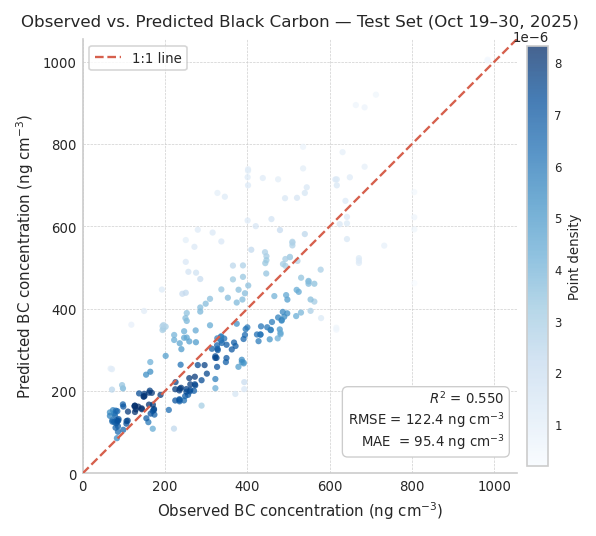

Figure 1 saved → fig1_scatter.png


In [123]:
fig1, ax = plt.subplots(figsize=(5.2, 4.8))

# Density colouring via KDE
xy  = np.vstack([obs_test, pred_test])
kde = gaussian_kde(xy)(xy)
sc  = ax.scatter(obs_test, pred_test, c=kde, cmap='Blues',
                 s=14, alpha=0.75, linewidths=0, zorder=3)
cb  = fig1.colorbar(sc, ax=ax, pad=0.02, shrink=0.82)
cb.set_label('Point density', fontsize=8)
cb.ax.tick_params(labelsize=7)

# 1:1 reference line
lim = max(obs_test.max(), pred_test.max()) * 1.05
ax.plot([0, lim], [0, lim], color=ORANGE, lw=1.4, ls='--', zorder=4, label='1:1 line')

# Annotation box
txt = (f'$R^2$ = {r2_C:.3f}\n'
       f'RMSE = {rmse_C:.1f} ng cm$^{{-3}}$\n'
       f'MAE  = {mae_C:.1f} ng cm$^{{-3}}$')
ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=8,
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=MGREY, lw=0.8))

ax.set_xlim(0, lim);  ax.set_ylim(0, lim)
ax.set_aspect('equal')
ax.set_xlabel('Observed BC concentration (ng cm$^{-3}$)')
ax.set_ylabel('Predicted BC concentration (ng cm$^{-3}$)')
ax.set_title('Observed vs. Predicted Black Carbon — Test Set (Oct 19–30, 2025)', pad=8)
ax.legend(fontsize=8, loc='upper left', frameon=True, edgecolor=MGREY)

plt.tight_layout()
plt.savefig('fig1_scatter.png')
plt.show()
print("Figure 1 saved → fig1_scatter.png")

**Figure 2 — Time Series (Training and Test)**

The split into two panels allows both periods to be shown at their natural time scales
without compressing either. The shaded area under the observed trace provides an
immediate visual sense of the concentration envelope; the coloured prediction line
sits on top. Underestimation during sharp formation events (rapid overnight rises)
is visible as a gap between the observed peak and the predicted trace.

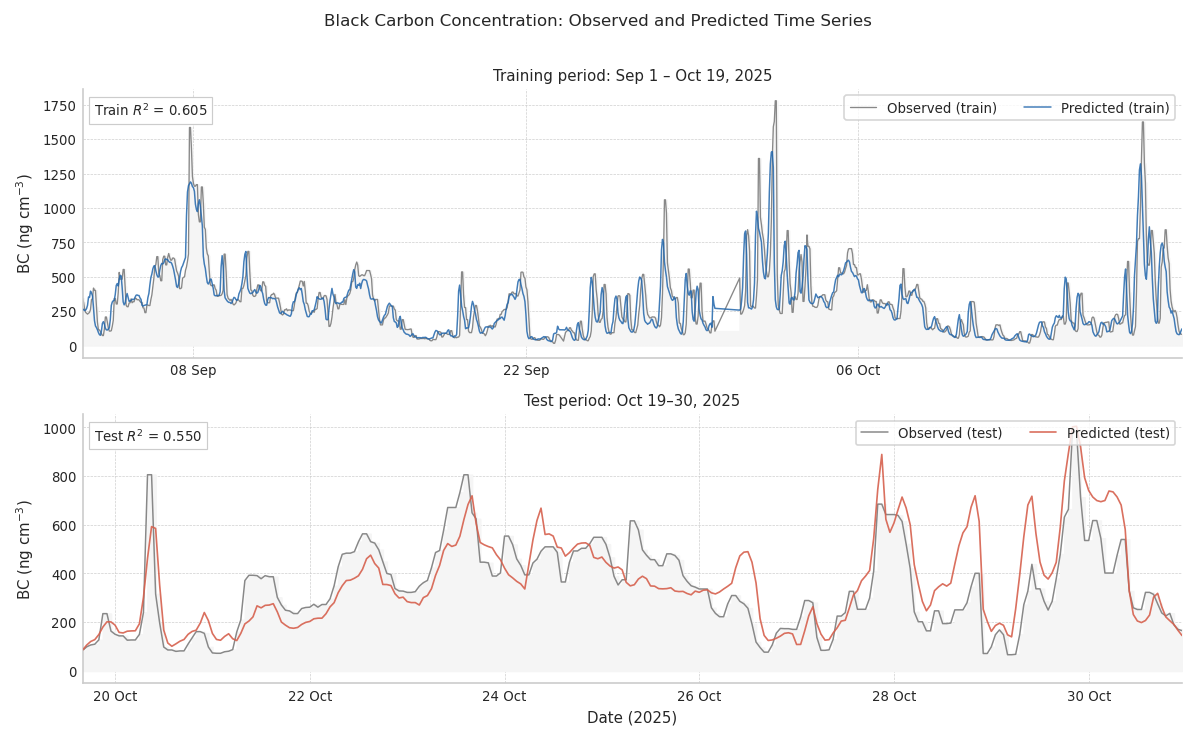

Figure 2 saved → fig2_timeseries.png


In [128]:
r2_train = float(np.corrcoef(obs_train, pred_train)[0, 1] ** 2)   # fast R² check

fig2, (ax_tr, ax_te) = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

# ── Training panel ────────────────────────────────────────────────────────────
ax_tr.fill_between(idx_train, 0, obs_train, color=LGREY, step='post', zorder=1)
ax_tr.plot(idx_train, obs_train,  color=GREY,  lw=0.8, zorder=2, label='Observed (train)')
ax_tr.plot(idx_train, pred_train, color=BLUE,  lw=0.9, alpha=0.85, zorder=3, label='Predicted (train)')
ax_tr.set_ylabel('BC (ng cm$^{-3}$)')
ax_tr.set_title('Training period: Sep 1 – Oct 19, 2025', fontsize=9, pad=5)
ax_tr.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
ax_tr.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_tr.set_xlim(idx_train[0], idx_train[-1])
ax_tr.text(0.01, 0.95, f'Train $R^2$ = {r2_train:.3f}',
           transform=ax_tr.transAxes, fontsize=8, va='top',
           bbox=dict(fc='white', ec=MGREY, pad=3, lw=0.7))
ax_tr.legend(fontsize=8, loc='upper right', frameon=True, edgecolor=MGREY, ncol=2)

# ── Test panel ────────────────────────────────────────────────────────────────
ax_te.fill_between(idx_test, 0, obs_test, color=LGREY, step='post', zorder=1)
ax_te.plot(idx_test, obs_test,  color=GREY,   lw=0.9, zorder=2, label='Observed (test)')
ax_te.plot(idx_test, pred_test, color=ORANGE, lw=1.0, alpha=0.90, zorder=3, label='Predicted (test)')
ax_te.set_ylabel('BC (ng cm$^{-3}$)')
ax_te.set_xlabel('Date (2025)')
ax_te.set_title('Test period: Oct 19–30, 2025', fontsize=9, pad=5)
ax_te.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax_te.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_te.set_xlim(idx_test[0], idx_test[-1])
ax_te.text(0.01, 0.95, f'Test $R^2$ = {r2_C:.3f}',
           transform=ax_te.transAxes, fontsize=8, va='top',
           bbox=dict(fc='white', ec=MGREY, pad=3, lw=0.7))
ax_te.legend(fontsize=8, loc='upper right', frameon=True, edgecolor=MGREY, ncol=2)

fig2.suptitle('Black Carbon Concentration: Observed and Predicted Time Series',
              y=1.01, fontsize=10)
plt.tight_layout()
plt.savefig('fig2_timeseries.png')
plt.show()
print("Figure 2 saved → fig2_timeseries.png")

**Figure 3 — Feature Importances**

Features are colour-coded by physical category so the narrative can be read visually:
combustion tracers (blue) are the primary signal; chemical aging proxies (green) encode
how far the plume has evolved since emission; dynamical and thermodynamic variables
account for transport and dilution. The modest scores of binary flags (Is\_Daylight,
BL\_Instability) reflect a known MDI bias rather than physical unimportance.

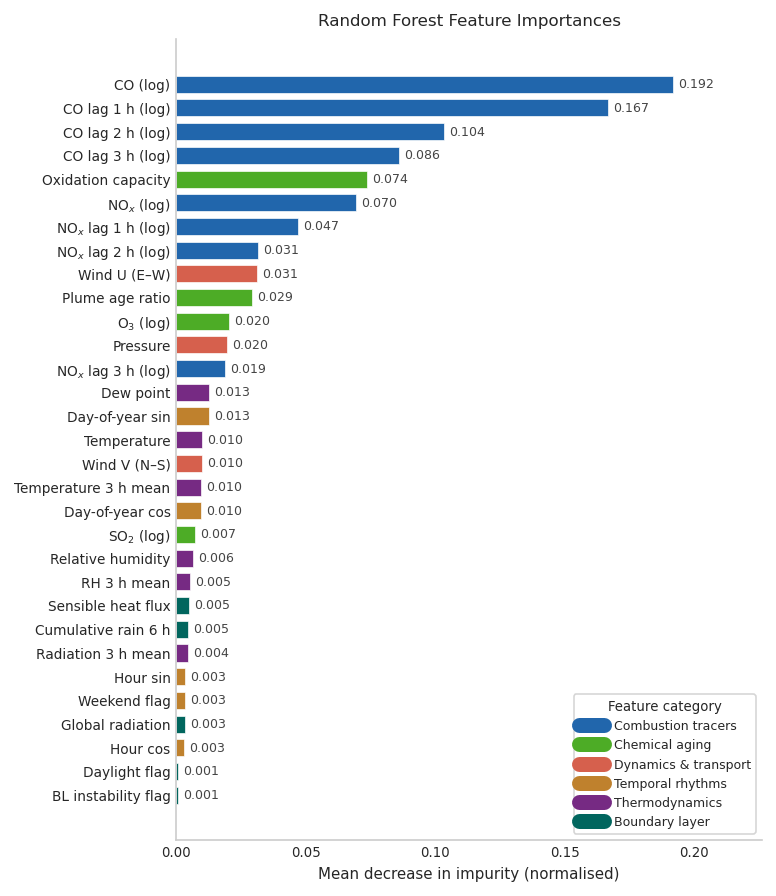

Figure 3 saved → fig3_importance.png


In [131]:
# ── Category map: raw feature name → (display label, category) ───────────────
CATEGORIES = {
    'log_CO':            ('CO (log)',              'Combustion tracers'),
    'log_CO_lag1':       ('CO lag 1 h (log)',       'Combustion tracers'),
    'log_CO_lag2':       ('CO lag 2 h (log)',       'Combustion tracers'),
    'log_CO_lag3':       ('CO lag 3 h (log)',       'Combustion tracers'),
    'log_NOx':           ('NO$_x$ (log)',           'Combustion tracers'),
    'log_NOx_lag1':      ('NO$_x$ lag 1 h (log)',  'Combustion tracers'),
    'log_NOx_lag2':      ('NO$_x$ lag 2 h (log)',  'Combustion tracers'),
    'log_NOx_lag3':      ('NO$_x$ lag 3 h (log)',  'Combustion tracers'),
    'Oxidation_Capacity':('Oxidation capacity',     'Chemical aging'),
    'Plume_Age_Ratio':   ('Plume age ratio',        'Chemical aging'),
    'log_O3':            ('O$_3$ (log)',            'Chemical aging'),
    'log_SO2':           ('SO$_2$ (log)',           'Chemical aging'),
    'Wind_U':            ('Wind U (E–W)',           'Dynamics & transport'),
    'Wind_V':            ('Wind V (N–S)',           'Dynamics & transport'),
    'Pressure':          ('Pressure',              'Dynamics & transport'),
    'DayOfYear_sin':     ('Day-of-year sin',        'Temporal rhythms'),
    'DayOfYear_cos':     ('Day-of-year cos',        'Temporal rhythms'),
    'Is_Weekend':        ('Weekend flag',           'Temporal rhythms'),
    'Hour_sin':          ('Hour sin',              'Temporal rhythms'),
    'Hour_cos':          ('Hour cos',              'Temporal rhythms'),
    'Temperature':       ('Temperature',           'Thermodynamics'),
    'Dew_Point':         ('Dew point',             'Thermodynamics'),
    'Relative_Humidity': ('Relative humidity',     'Thermodynamics'),
    'Temp_roll3':        ('Temperature 3 h mean',  'Thermodynamics'),
    'RH_roll3':          ('RH 3 h mean',           'Thermodynamics'),
    'Rad_roll3':         ('Radiation 3 h mean',    'Thermodynamics'),
    'Global_Radiation':  ('Global radiation',      'Boundary layer'),
    'Sensible_Heat_Flux':('Sensible heat flux',    'Boundary layer'),
    'BL_Instability':    ('BL instability flag',   'Boundary layer'),
    'Is_Daylight':       ('Daylight flag',         'Boundary layer'),
    'Cumulative_Rain_6h':('Cumulative rain 6 h',   'Boundary layer'),
}

CAT_COLORS = {
    'Combustion tracers':  '#2166ac',
    'Chemical aging':      '#4dac26',
    'Dynamics & transport':'#d6604d',
    'Temporal rhythms':    '#bf812d',
    'Thermodynamics':      '#762a83',
    'Boundary layer':      '#01665e',
}

labels, values, colors = [], [], []
for feat, imp in zip(FEAT_C, rf_C.feature_importances_):
    info = CATEGORIES.get(feat, (feat, 'Combustion tracers'))
    labels.append(info[0])
    values.append(imp)
    colors.append(CAT_COLORS[info[1]])

# Sort ascending for horizontal bar chart
order    = np.argsort(values)
labels_s = [labels[i] for i in order]
values_s = [values[i] for i in order]
colors_s = [colors[i] for i in order]

fig3, ax = plt.subplots(figsize=(6.5, 7.5))
bars = ax.barh(range(len(labels_s)), values_s, color=colors_s,
               height=0.72, edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, values_s):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=7.5, color='#444')

ax.set_yticks(range(len(labels_s)))
ax.set_yticklabels(labels_s, fontsize=8.2)
ax.set_xlabel('Mean decrease in impurity (normalised)')
ax.set_title('Random Forest Feature Importances', pad=8)
ax.set_xlim(0, max(values_s) * 1.18)
ax.grid(axis='x');  ax.grid(axis='y', linestyle='none')

legend_handles = [Line2D([0], [0], color=c, lw=9, label=cat)
                  for cat, c in CAT_COLORS.items()]
ax.legend(handles=legend_handles, fontsize=7.5, loc='lower right',
          title='Feature category', title_fontsize=8,
          frameon=True, edgecolor=MGREY)

plt.tight_layout()
plt.savefig('fig3_importance.png')
plt.show()
print("Figure 3 saved → fig3_importance.png")

**Figure 4 — Covariate Shift: Train vs. Test Distributions**

The Kolmogorov–Smirnov test showed that every meteorological feature shifts
significantly ($p < 0.05$) between training and test sets. This figure visualises
that shift directly for the three most physically important variables. The near-total
separation of the radiation distributions (centre panel) illustrates why a
Random Forest — which cannot extrapolate beyond training-set ranges — hits a hard
$R^2$ ceiling regardless of further feature engineering.

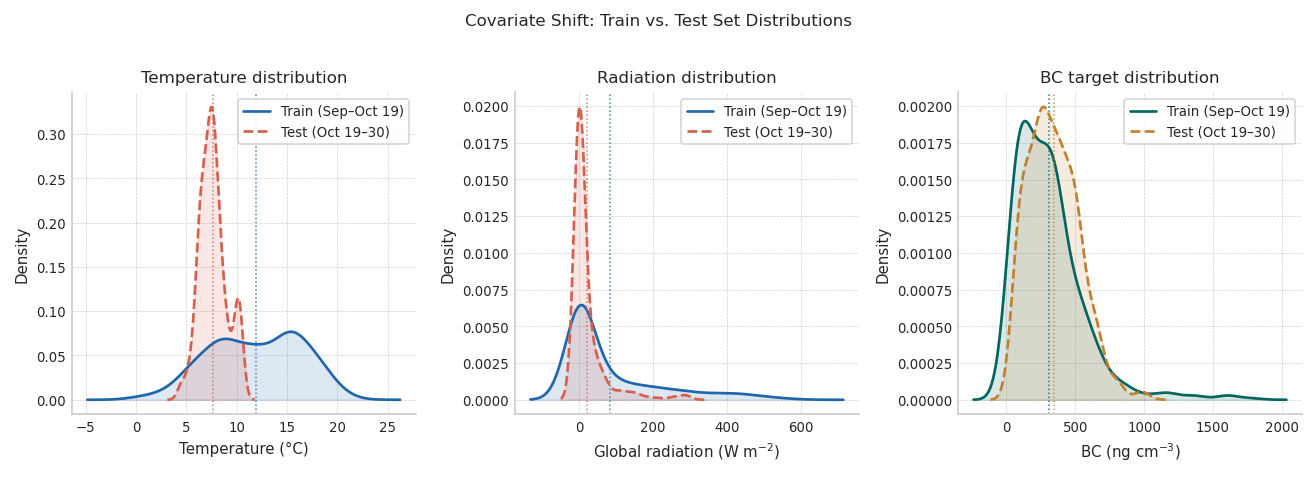

Figure 4 saved → fig4_covariate_shift.png


In [134]:
def kde_panel(ax, train_data, test_data, xlabel, title,
              c_train=BLUE, c_test=ORANGE):
    """Plot overlapping KDEs for train and test distributions."""
    for data, color, label, ls in [
        (train_data, c_train, f'Train (Sep–Oct 19)', '-'),
        (test_data,  c_test,  f'Test (Oct 19–30)',  '--'),
    ]:
        xs  = np.linspace(data.min() - data.std(), data.max() + data.std(), 300)
        kde = gaussian_kde(data, bw_method=0.3)
        ax.fill_between(xs, kde(xs), alpha=0.15, color=color)
        ax.plot(xs, kde(xs), color=color, lw=1.6, ls=ls, label=label)
        ax.axvline(data.mean(), color=color, lw=0.9, ls=':', alpha=0.85)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(title, pad=6)
    ax.legend(fontsize=8, frameon=True, edgecolor=MGREY)

temp_train = df_final['Temperature'].iloc[:split_idx].values
temp_test  = df_final['Temperature'].iloc[split_idx:].values
rad_train  = df_final['Global_Radiation'].iloc[:split_idx].values
rad_test   = df_final['Global_Radiation'].iloc[split_idx:].values

fig4, axes4 = plt.subplots(1, 3, figsize=(11, 3.8))

kde_panel(axes4[0], temp_train, temp_test,
          'Temperature (°C)', 'Temperature distribution')
kde_panel(axes4[1], rad_train, rad_test,
          'Global radiation (W m$^{-2}$)', 'Radiation distribution')
kde_panel(axes4[2], obs_train, obs_test,
          'BC (ng cm$^{-3}$)', 'BC target distribution',
          c_train=TEAL, c_test=AMBER)

fig4.suptitle('Covariate Shift: Train vs. Test Set Distributions', y=1.02, fontsize=10)
plt.tight_layout()
plt.savefig('fig4_covariate_shift.png')
plt.show()
print("Figure 4 saved → fig4_covariate_shift.png")
